正在加载数据集: ./data/inv_training_dataset_1d.npy ...
🧠 正在计算相对误差与特征聚合...
🎨 正在绘制高分辨率六边形热图...
✅ 热图绘制完成！已保存为: error_heatmap.png


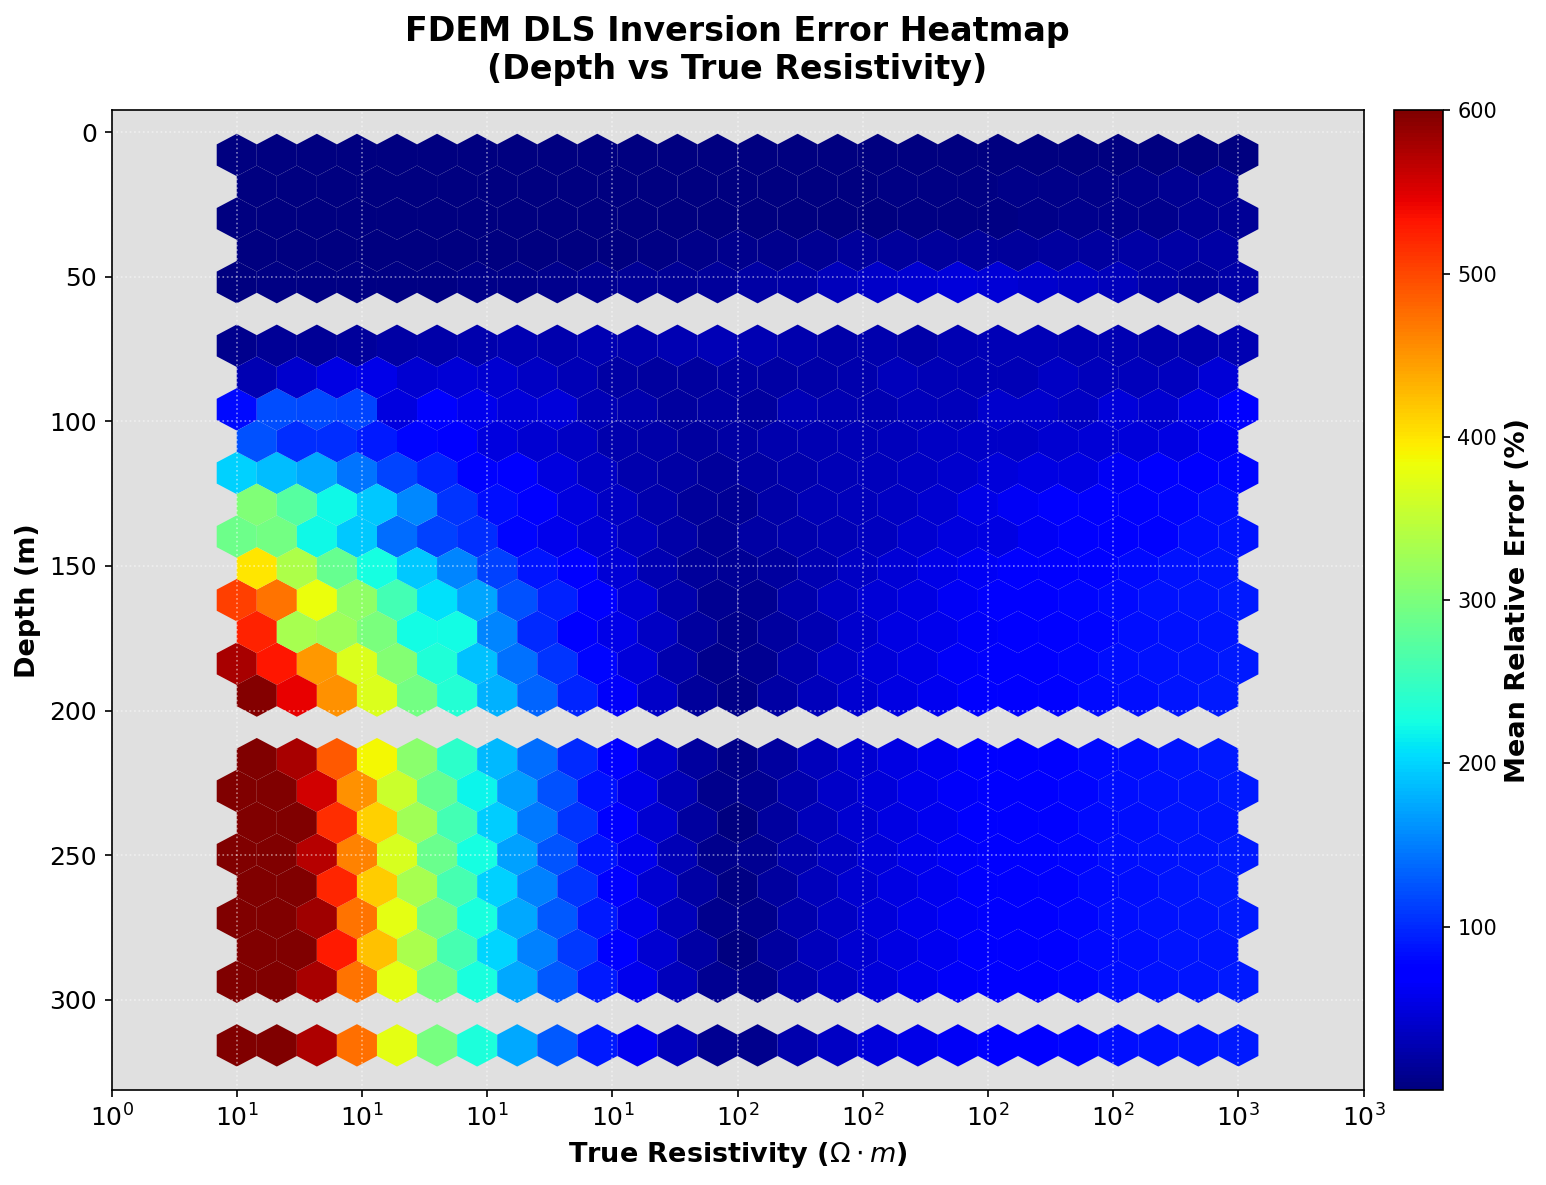

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_inversion_error_heatmap(data_path="./data/inv_training_dataset_1d.npy"):
    print(f"正在加载数据集: {data_path} ...")
    if not os.path.exists(data_path):
        print("❌ 找不到数据集，请确认数据流水线是否已完成！")
        return
        
    dataset = np.load(data_path, allow_pickle=True).item()
    
    m_true = dataset['ground_truth_m']     # 真实的电阻率 (N, n_layers)
    m_inv = dataset['input_m_fdem']        # DLS反演的电阻率 (N, n_layers)
    
    # 提取并计算每层的中心深度
    if dataset['thicknesses'].ndim > 1:
        hh = dataset['thicknesses'][0]
    else:
        hh = dataset['thicknesses']
        
    z_top = np.concatenate(([0], np.cumsum(hh[:-1])))
    z_center = z_top + np.concatenate((hh[:-1] / 2, [hh[-2]]))
    
    print("🧠 正在计算相对误差与特征聚合...")
    # 将 (N, 20) 的矩阵展平，因为我们要在 2D 空间上统计所有的网格点
    N = m_true.shape[0]
    depths_flat = np.tile(z_center, N)
    m_true_flat = m_true.flatten()
    m_inv_flat = m_inv.flatten()
    
    # 计算相对误差的百分比 (Relative Error %)
    # 公式: |反演值 - 真实值| / 真实值 * 100
    rel_error = np.abs((m_inv_flat - m_true_flat) / m_true_flat) * 100
    
    # 【可视化关键】将误差截断在 100% 
    # 因为电磁法对深部高阻体完全不敏感，反演值和真实值可能差了几十倍。
    # 如果不截断，热图的颜色色标会被极个别离群点拉垮，导致大部分区域全是一片蓝色。
    rel_error_clipped = np.clip(rel_error, 0, 600)
    
    # 对真实电阻率取对数，方便在 X 轴上做对数尺度的高斯/蜂窝散点聚合
    log_m_true_flat = np.log10(m_true_flat)
    
    print("🎨 正在绘制高分辨率六边形热图...")
    plt.figure(figsize=(11, 8), dpi=150)
    
    # 使用 hexbin 绘制六边形热图 (类似于 2D 直方图)
    # 它会自动把落入同一个 (深度, 电阻率) 六边形格子内的所有点，求出平均误差！
    hb = plt.hexbin(log_m_true_flat, depths_flat, C=rel_error_clipped, 
                    gridsize=25, cmap='jet', reduce_C_function=np.mean, 
                    edgecolors='none', mincnt=1)
    
    # 添加和美化色标
    cb = plt.colorbar(hb, pad=0.02)
    cb.set_label('Mean Relative Error (%)', fontsize=13, fontweight='bold')
    
    # 翻转 Y 轴 (让深度向下延伸)
    plt.gca().invert_yaxis()
    
    # 美化 X 轴：将对数转换回直观的科学计数法文本 (如 10^1, 10^2)
    locs = plt.xticks()[0]
    locs = locs[(locs >= 0) & (locs <= 5)] # 过滤掉画布外的多余刻度
    labels = [f"$10^{{{int(loc)}}}$" for loc in locs]
    plt.xticks(locs, labels, fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.title('FDEM DLS Inversion Error Heatmap\n(Depth vs True Resistivity)', fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('True Resistivity ($\Omega\cdot m$)', fontsize=13, fontweight='bold')
    plt.ylabel('Depth (m)', fontsize=13, fontweight='bold')
    
    plt.grid(True, linestyle=':', alpha=0.5, color='white')
    # 设置背景色为深灰，让数据点更凸显
    plt.gca().set_facecolor('#e0e0e0') 
    
    plt.tight_layout()
    save_path = "error_heatmap.png"
    plt.savefig(save_path)
    print(f"✅ 热图绘制完成！已保存为: {save_path}")

if __name__ == "__main__":
    plot_inversion_error_heatmap()